# Project 1

In [1]:
using LinearAlgebra, Plots, PrettyTables

In [2]:
function blurmatrix(n)
    return diagm(0 => ones(n)/2, 1 => ones(n-1)/4, -1 => ones(n-1)/4)
end

blurmatrix (generic function with 1 method)

## Conditioning

### (a)

The condition number of a matrix has two factors, $\|\bold{A}\|$ and $\|\bold{A}^{-1}\|$. First you will show that the $\|\bold{A}\|$ term makes no trouble. For $n=50,100,150,\ldots,800$, plot $\|\bold{B}_n\|$ versus $n$.

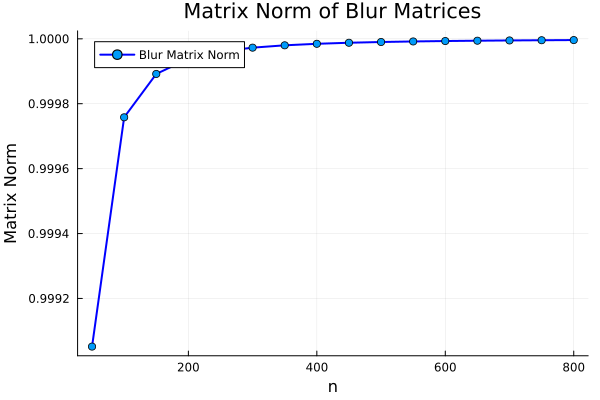

In [3]:
ns = 50:50:800
blur_matrices = blurmatrix.(ns)

# plot the matrix norm of the blur matrices
plot(ns, opnorm.(blur_matrices), 
     title="Matrix Norm of Blur Matrices", 
     xlabel="n", 
     ylabel="Matrix Norm", 
     label="Blur Matrix Norm", 
     legend=:topleft, 
     grid=true, 
     marker=:circle, 
     linecolor=:blue, 
     linewidth=2)

### (b)

For the same $n$ as in step 1, plot $\kappa(\bold{B}_n)$ versus $n$. You should use a log-log scale for this graph and get essentially a straight line. This implies that $\log \kappa \approx a \log n + b$, or $\kappa \approx C n^p$. (Note that you may see a straight line only for the first few values of $n$, after which the computer may struggle to accurately compute the condition number.)

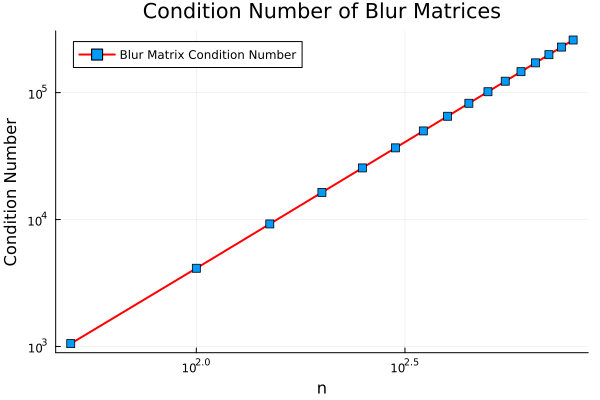

In [4]:
# plot condition number
plot(ns, cond.(blur_matrices), 
     title="Condition Number of Blur Matrices", 
     xlabel="n", 
     ylabel="Condition Number", 
     xaxis=:log,
     yaxis=:log,
     label="Blur Matrix Condition Number", 
     legend=:topleft, 
     grid=true, 
     marker=:square, 
     linecolor=:red, 
     linewidth=2)

### (c)

Let $\bold{V}=\bold{B}_{100}$. For $k=1,2,\ldots,8$, plot $\kappa(\bold{V}^k)$ as a function of $k$. This time the graph is straight on a semi-log scale, which implies $\kappa \approx C q^k$. 

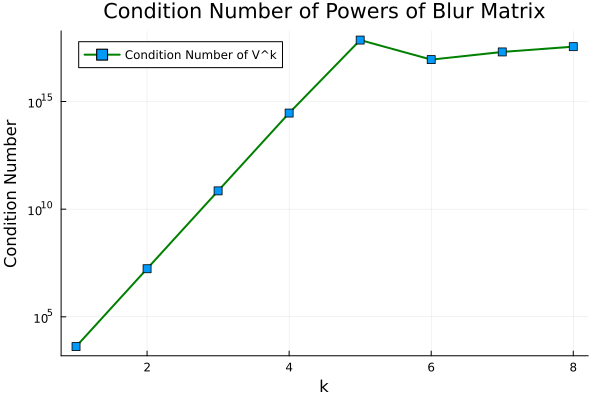

In [5]:
V = blurmatrix(100)
k = 1:1:8
Vk = [V^i for i in k]
condVk = cond.(Vk)

plot(k, condVk, 
     title="Condition Number of Powers of Blur Matrix", 
     xlabel="k", 
     ylabel="Condition Number", 
     yaxis=:log,
     label="Condition Number of V^k", 
     legend=:topleft, 
     grid=true, 
     marker=:square, 
     linecolor=:green, 
     linewidth=2)

### (d) / (e)

Let $\bold{x}$ be a random vector of length 100. For $k=1,2,\ldots,8$, let $\bold{z}=\bold{V}^k\bold{x}$ and then solve $\bold{V}^k\bold{y}=\bold{z}$ for $\bold{y}$. Record the relative error in the result. Then make a table showing both sides of the inequality 2.

How many digits of accuracy do you expect for $k = 1, 2, \cdots, 8$ in the bound above?

In [ ]:
# create random vector of length 100
x = rand(100)
zs = [V^i * x for i in k]

# solve V^k y = z for y
ys = [V^i \ z for (i, z) in zip(k, zs)]

# calaculate relative error
rel_errors = [norm(ys[i] - x) / norm(x) for i in k]

# calculate accurate digits
machine_epsilon = eps(Float64)
kVe = [cond(V^i) * machine_epsilon for i in k]
accurate_digits = [log10(1 / rel_errors[i]) for i in k]
accurate_digits = [max(0, floor(accurate_digits[i])) for i in k] # ensure non-negative

# make table to show the results
table_data = hcat(k, rel_errors, kVe, accurate_digits)
header = ["Power k", "Relative Error", "Condition Number * ε", "Accurate Digits"]
pretty_table(table_data, header = header, header_crayon = crayon"yellow bold")

┌─────────┬────────────────┬──────────────────────┬─────────────────┐
│ Power k │ Relative Error │ Condition Number * ε │ Accurate Digits │
├─────────┼────────────────┼──────────────────────┼─────────────────┤
│     1.0 │    1.23551e-14 │          9.17853e-13 │            13.0 │
│     2.0 │    2.93052e-10 │           3.79408e-9 │             9.0 │
│     3.0 │     5.81621e-7 │           1.56834e-5 │             6.0 │
│     4.0 │     0.00377904 │            0.0646954 │             2.0 │
│     5.0 │        4.40974 │              158.516 │             0.0 │
│     6.0 │         49.486 │              19.6018 │             0.0 │
│     7.0 │         2.8922 │              44.4909 │             0.0 │
│     8.0 │        6.50244 │              78.3829 │             0.0 │
└─────────┴────────────────┴──────────────────────┴─────────────────┘
